In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
def LoadData(X_filename,Y_filename):
    '''
    Input: Get 2 filenames, 1 for x_data and 1 for y_data
    Output: Two numpy array of X and Y data
    '''
    X = pd.read_csv(X_filename,delimiter=';')
    Y = pd.read_csv(Y_filename,delimiter=';')
    X = X.to_numpy()
    Y = Y.to_numpy()
    return X,Y
    

In [3]:
def GetFeatureNames(X_filename):
    X = pd.read_csv(X_filename,delimiter=';')
    feature_names = X.columns
    return feature_names

In [5]:
def SplitTrainTestRandom(X,Y):
    '''
    ***COMPLETED - NO CHANGES ARE REQUIRED***
    
    Input: feature matrix X, labels vector Y
    Output: X_train, Y_train - train data
            X_test, Y_test - test data
    '''
    
    # permute the ordering of the examples
    # random inds every running 
    ind = np.random.permutation(len(Y))
    
    # choose the size of the training data
    Ntrain = int(0.8 * len(Y))
    # split the data into train and test datasets
    
    X_train = X[ind[:Ntrain]]
    Y_train = Y[ind[:Ntrain]]
    X_test  = X[ind[Ntrain:]]
    Y_test  = Y[ind[Ntrain:]]
    
    return X_train, Y_train, X_test, Y_test

In [13]:
X,Y = LoadData("X_data.csv","Y_data.csv")

running_num = 50
acc = np.array([])
for i in range(running_num):
    X_train, Y_train, X_test, Y_test = SplitTrainTestRandom(X,Y)
    clf = GaussianNB().fit(X_train,Y_train)
    acc = np.append(acc,clf.score(X_test,Y_test))


print(f'The average accuracy for {running_num} runs is {acc.mean()}')



The average accuracy for 50 runs is 0.7129558998808104


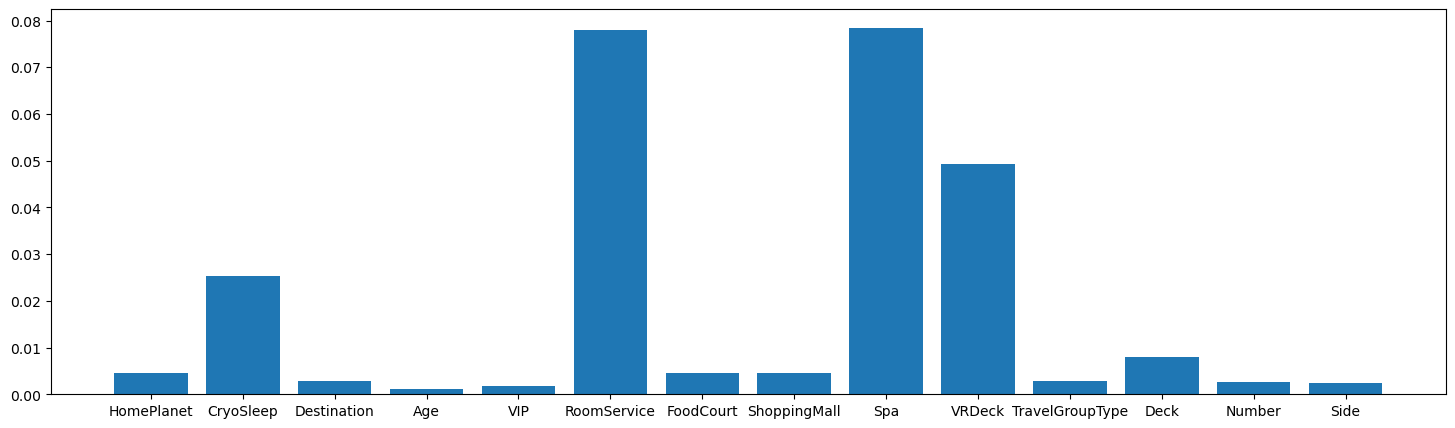

In [19]:
from sklearn.inspection import permutation_importance
feature_names = GetFeatureNames("X_data.csv")
result = permutation_importance(clf, X_test, Y_test, n_repeats=30, random_state=42)
importances = result.importances_mean

plt.figure(figsize=(18,5))
plt.bar(range(len(importances)), importances) 
plt.xticks(ticks=range(len(feature_names)),labels=feature_names)
plt.show()